In [9]:
import pandas as pd
import numpy as np

# Semilla para que los números aleatorios sean siempre los mismos
np.random.seed(42)
n_clientes = 1000

# Generamos variables de comportamiento
edad = np.random.randint(18, 80, n_clientes)
antiguedad = np.random.randint(1, 120, n_clientes)
prima = np.random.uniform(3000, 15000, n_clientes)
siniestros = np.random.poisson(0.5, n_clientes)
quejas = np.random.poisson(0.2, n_clientes)

# Simulamos la probabilidad de fuga (Churn) basada en reglas ocultas
prob_churn = (quejas * 0.3) + (prima > 10000) * 0.2 + (edad < 25) * 0.2 - (antiguedad > 60) * 0.2
prob_churn = np.clip(prob_churn, 0.05, 0.95)
churn = np.random.binomial(1, prob_churn) # 1 = Se dio de baja, 0 = Sigue activo

# Armamos el DataFrame y exportamos
df_churn = pd.DataFrame({
    'Edad': edad,
    'Antiguedad_Meses': antiguedad,
    'Prima_Mensual': prima.round(2),
    'Siniestros_Previos': siniestros,
    'Quejas': quejas,
    'Fuga_Churn': churn
})

df_churn.to_csv('clientes_seguros_churn.csv', index=False)
print("¡Archivo 'clientes_seguros_churn.csv' generado con éxito!")

¡Archivo 'clientes_seguros_churn.csv' generado con éxito!


In [10]:
#1

df = pd.read_csv('clientes_seguros_churn.csv')
X = df.drop('Fuga_Churn', axis=1)
y = df['Fuga_Churn']

In [11]:
#2
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
#3
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [13]:
#4
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, confusion_matrix
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.865
[[167   4]
 [ 23   6]]


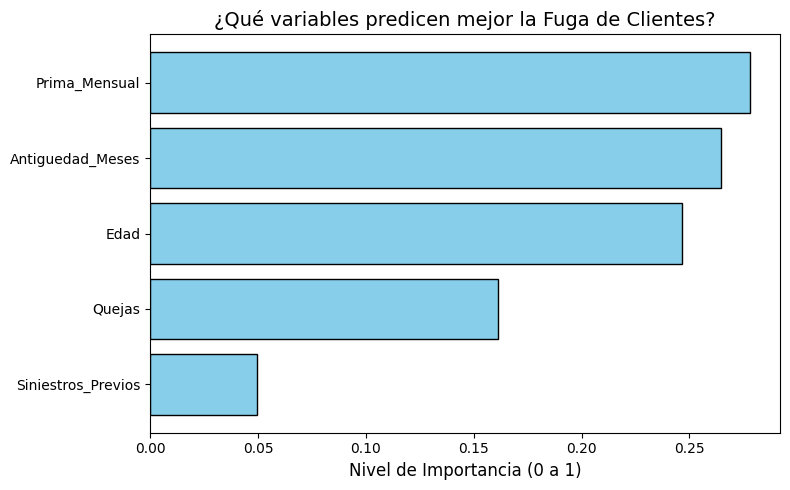

In [14]:
#5
import numpy as np
import matplotlib.pyplot as plt

# 1. Obtener los nombres y las importancias
importances = model.feature_importances_
feature_names = X.columns

# 2. Ordenar los índices de menor a mayor
indices = np.argsort(importances)

# 3. Dibujar el gráfico ordenado y mejore de diseño
plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), importances[indices], color='skyblue', edgecolor='black')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Nivel de Importancia (0 a 1)', fontsize=12)
plt.title('¿Qué variables predicen mejor la Fuga de Clientes?', fontsize=14)

# 4. Ajustar márgenes, guardar y mostrar
plt.tight_layout()
plt.savefig('importancia_variables_churn.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Rehacemos y mejoramos punto 4 para ajustar el umbral de riesgo y evaluar su impacto en el negocio:

# 1. Extraer las probabilidades
# Usamos [:, 1] para decirle a Python: "De todas las filas, dame solo la Columna 1 (Probabilidad de Fuga)"
probabilidades_fuga = model.predict_proba(X_test)[:, 1]

# 2. Definir nuestro propio umbral de riesgo (Ejemplo: 20%)
umbral_riesgo = 0.20

# 3. Crear nuevas predicciones: Si la prob es mayor o igual al umbral, lo marcamos como 1 (Fuga), sino 0.
# astype(int) convierte los Verdaderos/Falsos en 1s y 0s matemáticos.
y_pred_ajustado = (probabilidades_fuga >= umbral_riesgo).astype(int)

# 4. Evaluar el impacto en el negocio con una nueva Matriz de Confusión
from sklearn.metrics import confusion_matrix
print("Matriz de Confusión con umbral del 20%:")
print(confusion_matrix(y_test, y_pred_ajustado))

Matriz de Confusión con umbral del 20%:
[[138  33]
 [ 14  15]]


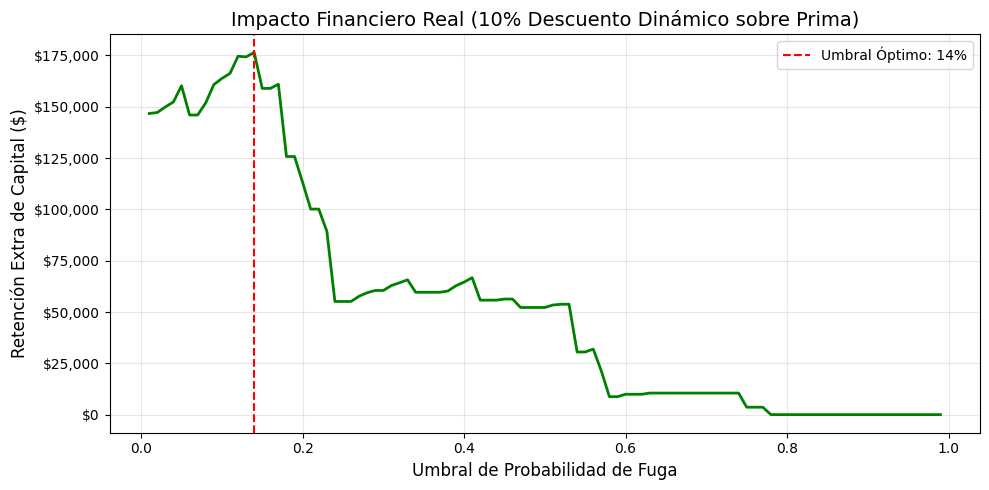

Umbral Óptimo Matemático: 14% de riesgo.
Retención neta máxima usando el modelo: $176,473.56


In [16]:
# Buscamos una oportunidad de mejora iterando con diferentes umbrales

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Extraemos las probabilidades y los datos reales fila por fila
probabilidades_fuga = model.predict_proba(X_test)[:, 1]
primas = X_test['Prima_Mensual'].values
y_reales = y_test.values

umbrales_a_probar = np.arange(0.01, 1.0, 0.01)
ahorros_financieros = []

# 2. El escenario base (Status Quo): Si no tuviéramos este modelo de Machine Learning,
# solo cobraríamos la prima completa de la gente que NO se fuga (y_reales == 0)
ingreso_sin_modelo = np.sum(primas[y_reales == 0])

# 3. Iteramos cada umbral posible
for umbral in umbrales_a_probar:
    y_pred_simulado = (probabilidades_fuga >= umbral).astype(int)
    
    ingreso_con_modelo = 0
    # Evaluamos cliente por cliente
    for i in range(len(y_pred_simulado)):
        # Si predecimos fuga (le damos el 10% de descuento)
        if y_pred_simulado[i] == 1:
            # Lo salvamos (True Positive) o gastamos sin necesidad (False Positive)
            # En ambos casos, ahora nos paga el 90% de su prima
            ingreso_con_modelo += 0.90 * primas[i]
            
        # Si predecimos que se queda (no hacemos nada)
        else:
            if y_reales[i] == 0:
                # Se quedó por su cuenta (True Negative), paga el 100%
                ingreso_con_modelo += primas[i]
            else:
                # Se nos escapó (False Negative), perdimos al cliente y paga 0
                ingreso_con_modelo += 0
                
    # El valor agregado de nuestro modelo es el dinero extra que retiene vs no hacer nada
    ahorro_neto = ingreso_con_modelo - ingreso_sin_modelo
    ahorros_financieros.append(ahorro_neto)

# 4. Encontramos el punto óptimo
indice_mejor_resultado = np.argmax(ahorros_financieros)
umbral_optimo = umbrales_a_probar[indice_mejor_resultado]
maxima_ganancia = ahorros_financieros[indice_mejor_resultado]

# 5. Graficamos la curva corregida
plt.figure(figsize=(10, 5))
plt.plot(umbrales_a_probar, ahorros_financieros, color='green', linewidth=2)
plt.axvline(umbral_optimo, color='red', linestyle='dashed', 
            label=f'Umbral Óptimo: {umbral_optimo*100:.0f}%')

plt.title('Impacto Financiero Real (10% Descuento Dinámico sobre Prima)', fontsize=14)
plt.xlabel('Umbral de Probabilidad de Fuga', fontsize=12)
plt.ylabel('Retención Extra de Capital ($)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('curva_optimizacion_financiera.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Umbral Óptimo Matemático: {umbral_optimo*100:.0f}% de riesgo.")
print(f"Retención neta máxima usando el modelo: ${maxima_ganancia:,.2f}")